In [1]:
import numpy as np
import pandas as pd
import time

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
x = df.drop(columns=['Purchased'])

In [5]:
y = df['Purchased']

In [6]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

In [8]:
X_scaled.shape

(400, 2)

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=2)

In [10]:
X_train.shape 

(320, 2)

In [11]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [12]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/opt/anaconda3/envs/ai_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-03 06:29:59.731338: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-03-03 06:29:59.731374: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-03 06:29:59.731383: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-03 06:29:59.731402: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-03 06:29:59.731420: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created 

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled,y,epochs=50,batch_size=1,validation_split=0.2)
print(time.time() - start)

Epoch 1/50


2026-03-03 06:30:00.142954: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8375 - loss: 0.3780 - val_accuracy: 0.8750 - val_loss: 0.3706
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8469 - loss: 0.3446 - val_accuracy: 0.8000 - val_loss: 0.3705
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8500 - loss: 0.3525 - val_accuracy: 0.8125 - val_loss: 0.3680
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8500 - loss: 0.3620 - val_accuracy: 0.8125 - val_loss: 0.3679
Epoch 5/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8531 - loss: 0.3588 - val_accuracy: 0.8125 - val_loss: 0.3466
Epoch 6/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8562 - loss: 0.3685 - val_accuracy: 0.8125 - val_loss: 0.3495
Epoch 7/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8469 - loss: 0.3713 - val_accuracy: 0.8125 - val_loss: 0.3557
Epoch 8/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8500 - loss: 0.3768 - val_accuracy: 0.8125 - val_

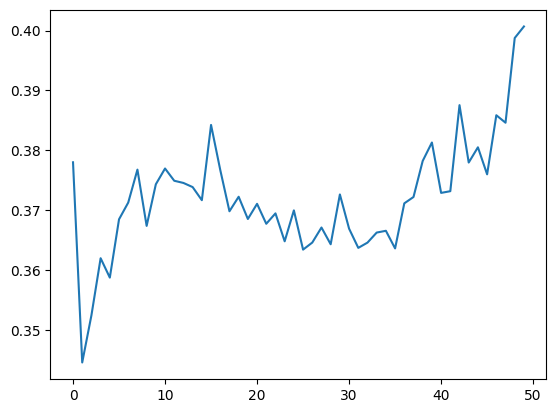

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [17]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/opt/anaconda3/envs/ai_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(X_scaled,y,epochs=10,batch_size=250,validation_split=0.2)
#print(time.time() - start)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 625ms/step - accuracy: 0.8219 - loss: 0.6030 - val_accuracy: 0.8000 - val_loss: 0.6084
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8375 - loss: 0.5746 - val_accuracy: 0.8375 - val_loss: 0.5916
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8406 - loss: 0.5554 - val_accuracy: 0.8500 - val_loss: 0.5809
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8375 - loss: 0.5413 - val_accuracy: 0.8625 - val_loss: 0.5741
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8375 - loss: 0.5308 - val_accuracy: 0.8750 - val_loss: 0.5636
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8375 - loss: 0.5199 - val_accuracy: 0.8875 - val_loss: 0.5564
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8375 - loss: 0.5110 - val_accuracy: 0.8750 - val_loss: 0.5510
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8375 - loss: 0.5028 - val_accuracy: 0.9000 - val_loss: 0.5443

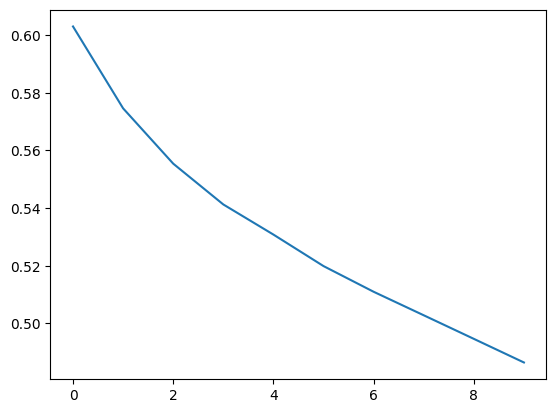

In [19]:
plt.plot(history.history['loss'])